# Livrable 2 :

In [2]:
import tensorflow as tf
import numpy as np
import os
import sys
from tensorflow import keras

project_root = os.path.abspath(os.path.join(".."))  # One level up from current script
if project_root not in sys.path:
    sys.path.append(project_root)

from src.model_loader import ModelLoader
from src.data_loader import DataLoader
from src.utils import get_confusion_matrix, get_classification_report

print(tf.__version__)

2.19.0


## Généation du dataset de photos

In [3]:
data_loader = DataLoader()
train_ds, test_ds, val_ds = data_loader.load_unique_dataset(folder_name="/mnt/c/Users/louag/Documents/CESI/Data_science/datasets/Photo")


Photo Dataset size: 9993


I0000 00:00:1744958901.897504    2642 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Bruitage du dataset

In [4]:
noisy_train_ds = data_loader.add_noise_to_dataset(train_ds)
noisy_val_ds = data_loader.add_noise_to_dataset(val_ds)
noisy_test_ds = data_loader.add_noise_to_dataset(test_ds)

In [26]:
noisy_test2_ds = data_loader.add_noise_to_dataset(test_ds, noise_factor=0.05)

In [5]:
from keras.layers import Input, Conv2D, BatchNormalization, LeakyReLU
from keras.models import Model

encoder_inputs = Input(shape=(256, 256, 3))  # Image RGB 256x256

# --- Block 1 ---
x1 = Conv2D(32, (3, 3), strides=2, padding='same')(encoder_inputs)  # (128, 128, 32)
x1 = BatchNormalization()(x1)
x1 = LeakyReLU()(x1)

# --- Block 2 ---
x2 = Conv2D(64, (3, 3), strides=2, padding='same')(x1)  # (64, 64, 64)
x2 = BatchNormalization()(x2)
x2 = LeakyReLU()(x2)

# --- Block 3 ---
x3 = Conv2D(128, (3, 3), strides=2, padding='same')(x2)  # (32, 32, 128)
x3 = BatchNormalization()(x3)
x3 = LeakyReLU()(x3)

# --- Block 4 ---
x4 = Conv2D(256, (3, 3), strides=2, padding='same')(x3)  # (16, 16, 256)
x4 = BatchNormalization()(x4)
x4 = LeakyReLU()(x4)

# --- Block 5 ---
x5 = Conv2D(256, (3, 3), strides=2, padding='same')(x4)  # (8, 8, 256)
x5 = BatchNormalization()(x5)
x5 = LeakyReLU()(x5)

# Sorties : encoder_output + features pour skip connections
encoder = Model(inputs=encoder_inputs, outputs=[x5, x4, x3, x2, x1], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 981,440 (3.74 MB)

 Trainable params: 979,968 (3.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [6]:
from keras.layers import Conv2DTranspose, Concatenate, Input, BatchNormalization, LeakyReLU
from keras.models import Model

# Entrées : latent + les 4 couches skip
latent_input = Input(shape=(8, 8, 256))     # Sortie finale de l'encodeur
skip4 = Input(shape=(16, 16, 256))
skip3 = Input(shape=(32, 32, 128))
skip2 = Input(shape=(64, 64, 64))
skip1 = Input(shape=(128, 128, 32))

x = latent_input

# Decode Block 1
x = Conv2DTranspose(256, (3, 3), strides=2, padding='same')(x)  # (16, 16, 256)
x = Concatenate()([x, skip4])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 2
x = Conv2DTranspose(128, (3, 3), strides=2, padding='same')(x)  # (32, 32, 128)
x = Concatenate()([x, skip3])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 3
x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)  # (64, 64, 64)
x = Concatenate()([x, skip2])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 4
x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)  # (128, 128, 32)
x = Concatenate()([x, skip1])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 5 - reconstruction finale
x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)  # (256, 256, 32)
decoder_output = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Modèle
decoder = Model(inputs=[latent_input, skip4, skip3, skip2, skip1], outputs=decoder_output, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 8, 8, 256) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    590,080 │ input_layer_1[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 16, 16,    │          0 │ -                 │
│ (InputLayer)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │    589,952 │ leaky_re_lu_5[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 64, 64,    │    147,520 │ leaky_re_lu_6[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ concatenate_2[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 128, 128,  │     36,896 │ leaky_re_lu_7[0]

 Total params: 1,387,619 (5.29 MB)

 Trainable params: 1,385,699 (5.29 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [7]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 8, 8, 256) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    590,080 │ input_layer_1[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 16, 16,    │          0 │ -                 │
│ (InputLayer)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │    589,952 │ leaky_re_lu_5[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 64, 64,    │    147,520 │ leaky_re_lu_6[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ concatenate_2[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 128, 128,  │     36,896 │ leaky_re_lu_7[0]

 Total params: 1,387,619 (5.29 MB)

 Trainable params: 1,385,699 (5.29 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [8]:
# -- Metrics Custom --
def ssim_metric(y_true, y_pred):
    # SSIM attend des valeurs entre [0, 1], donc il est important de s'assurer que les images sont dans cette plage.
    y_true = tf.clip_by_value(y_true, 0.0, 1.0)  # Pour être sûr que les valeurs sont entre [0, 1]
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)  # Pour être sûr que les valeurs sont entre [0, 1]
    
    # Calcul du SSIM sur les images RGB
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))  # max_val=1.0 pour les images normalisées

def psnr_metric(y_true, y_pred):
    # PSNR attend des valeurs entre [0, 1], donc on s'assure que les images sont dans cette plage.
    y_true = tf.clip_by_value(y_true, 0.0, 1.0)  # Normalisation entre [0, 1]
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)  # Normalisation entre [0, 1]
    
    # Calcul du PSNR sur les images RGB
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))  # max_val=1.0 pour les images normalisées


In [9]:
from tensorflow.keras.models import Model

encoder_outputs = encoder(encoder_inputs)
decoded_img = decoder(encoder_outputs)

autoencoder = Model(inputs=encoder_inputs, outputs=decoded_img)

# Compilation de l'autoencodeur
autoencoder.compile(optimizer="adam", loss="mae", metrics=["mae", ssim_metric, psnr_metric])

# Résumé du modèle
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ [(None, 8, 8,     │    981,440 │ input_layer[0][0] │
│ (Functional)        │ 256), (None, 16,  │            │                   │
│                     │ 16, 256), (None,  │            │                   │
│                     │ 32, 32, 128),     │            │                   │
│                     │ (None, 64, 64,    │            │                   │
│                     │ 64), (None, 128,  │            │                   │
│                     │ 128, 32)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 256, 256,  │  1,387,619 │ encoder[0][0],    │
│ (Functional)        │ 3)                │            │ encoder[0][1],    │
│                     │                   │            │ encoder[0][2],    │
│                     │                   │            │ encoder[0][3],    │
│                     │                   │            │ encoder[0][4]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,369,059 (9.04 MB)

 Trainable params: 2,365,667 (9.02 MB)

 Non-trainable params: 3,392 (13.25 KB)

In [10]:
@tf.autograph.experimental.do_not_convert
def make_autoencoder_dataset(input_ds, target_ds):
    return tf.data.Dataset.zip((input_ds.map(lambda x, y: x), target_ds.map(lambda x, y: x)))

In [11]:
train_autoenc_ds = make_autoencoder_dataset(noisy_train_ds, train_ds)
val_autoenc_ds = make_autoencoder_dataset(noisy_val_ds, val_ds)

In [12]:
# Train the model
with tf.device("/gpu:0"):
    history = autoencoder.fit(train_autoenc_ds,
                    epochs=100,
                    batch_size= 32,
                    shuffle= True,
                    validation_data=val_autoenc_ds,
                    verbose=1
                   )

Epoch 1/100


I0000 00:00:1744958907.603196    2740 service.cc:152] XLA service 0x7f69101295d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744958907.603263    2740 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
2025-04-18 08:48:28.166067: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-18 08:48:29.199261: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-04-18 08:48:29.202038: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-04-18 08:48:29.203632: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-04-18 08:48:29.209097: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/A

199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0999 - mae: 0.0999 - psnr_metric: 18.2105 - ssim_metric: 0.3355

2025-04-18 08:49:01.947209: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-04-18 08:49:01.947421: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-04-18 08:49:01.947574: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-04-18 08:49:01.947661: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert
2025-04-18 08:49:01.950173: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator PSNR/Assert/Assert
2025-04-18 08:49:01.950312: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator PSNR/Assert_1/Assert
2025-04-18 08:49:15.136726: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 16 bytes spill stores, 16 bytes spi

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.0998 - mae: 0.0998 - psnr_metric: 18.2173 - ssim_metric: 0.3359

2025-04-18 08:49:16.387588: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-04-18 08:49:16.389065: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-04-18 08:49:16.389857: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-04-18 08:49:16.390477: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert
2025-04-18 08:49:16.449370: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator PSNR/Assert/Assert
2025-04-18 08:49:16.450899: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator PSNR/Assert_1/Assert
2025-04-18 08:49:20.243349: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-04-18 08:49:20.243613: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSI

200/200 ━━━━━━━━━━━━━━━━━━━━ 60s 191ms/step - loss: 0.0997 - mae: 0.0997 - psnr_metric: 18.2239 - ssim_metric: 0.3362 - val_loss: 0.1590 - val_mae: 0.1590 - val_psnr_metric: 14.6378 - val_ssim_metric: 0.3982
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 23s 115ms/step - loss: 0.0697 - mae: 0.0697 - psnr_metric: 20.5445 - ssim_metric: 0.4835 - val_loss: 0.0845 - val_mae: 0.0845 - val_psnr_metric: 19.3601 - val_ssim_metric: 0.4838
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - loss: 0.0661 - mae: 0.0661 - psnr_metric: 20.9261 - ssim_metric: 0.5145 - val_loss: 0.0716 - val_mae: 0.0716 - val_psnr_metric: 20.3315 - val_ssim_metric: 0.5270
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0637 - mae: 0.0637 - psnr_metric: 21.1966 - ssim_metric: 0.5379 - val_loss: 0.0709 - val_mae: 0.0709 - val_psnr_metric: 20.3581 - val_ssim_metric: 0.5293
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - loss: 0.0624 - mae: 0.0624 - psnr_metric: 21.3596 - ssim_metric: 0.5499 - 

In [13]:
import datetime

# Récupérer la date et l'heure actuelle
now = datetime.datetime.now()
timestamp = now.strftime("%d%m%Y_%H%M")  # Format : jour mois année _ heure minute

# Construire le chemin de sauvegarde
save_path = f"./../models/autoencoder_skip_layer_mae_{timestamp}.weights.h5"

# Sauvegarder
autoencoder.save_weights(save_path)


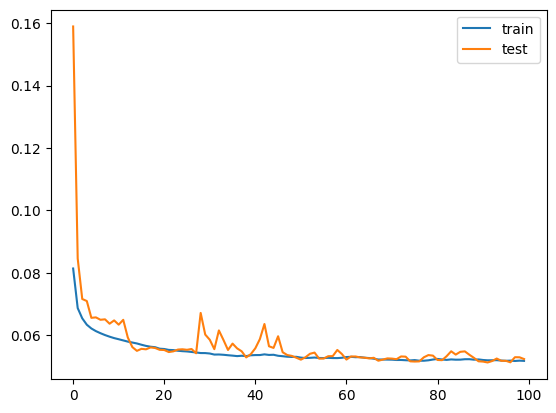

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()


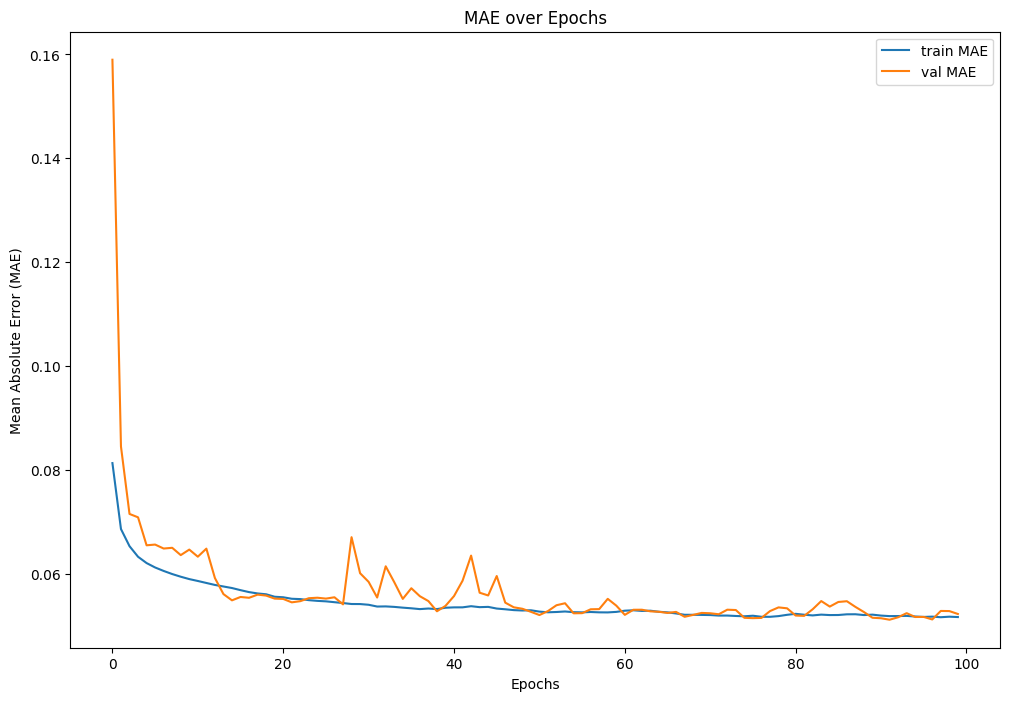

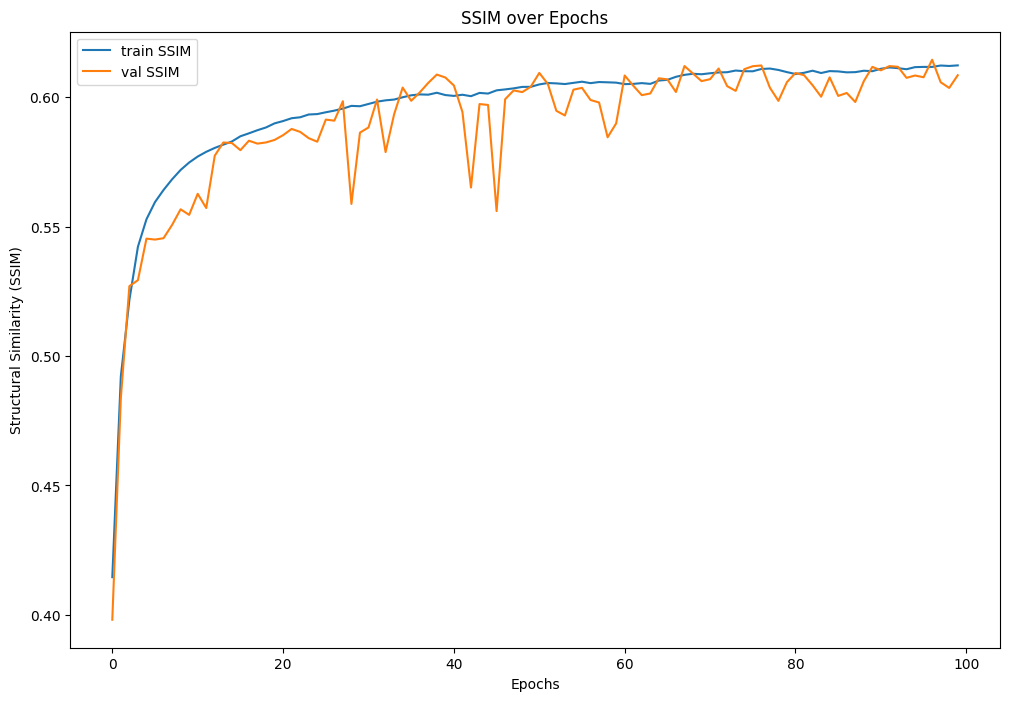

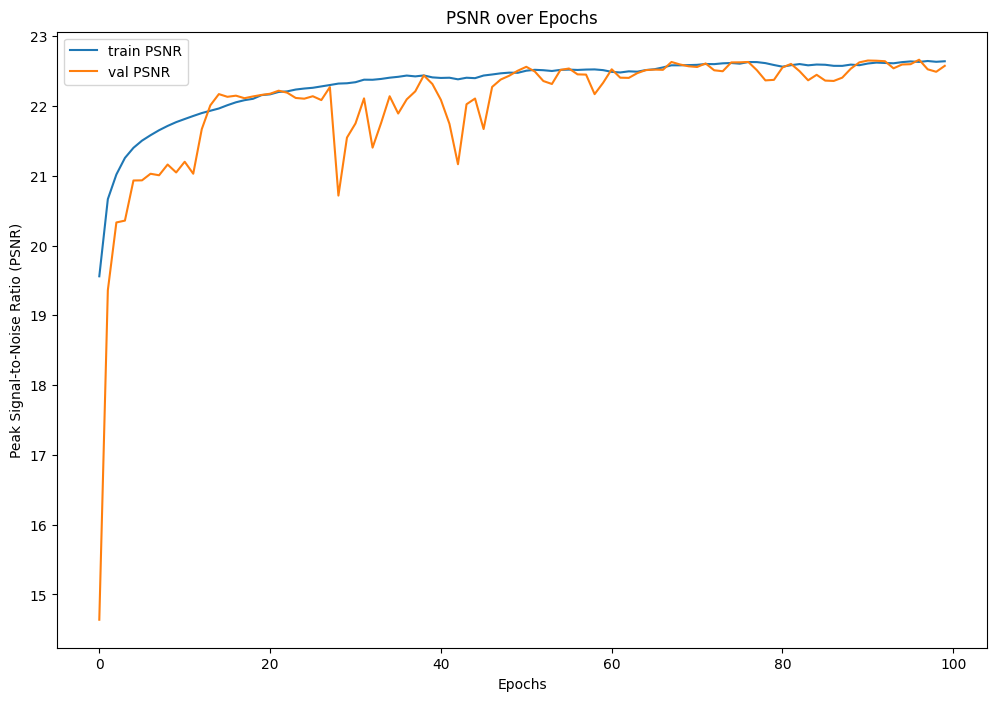

In [15]:
import matplotlib.pyplot as plt

# Tracer l'évolution de MAE
plt.figure(figsize=(12, 8))
plt.plot(history.history['mae'], label='train MAE')
plt.plot(history.history['val_mae'], label='val MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE over Epochs')
plt.legend()
plt.show()

# Tracer l'évolution de SSIM
plt.figure(figsize=(12, 8))
plt.plot(history.history['ssim_metric'], label='train SSIM')
plt.plot(history.history['val_ssim_metric'], label='val SSIM')
plt.xlabel('Epochs')
plt.ylabel('Structural Similarity (SSIM)')
plt.title('SSIM over Epochs')
plt.legend()
plt.show()

# Tracer l'évolution de PSNR
plt.figure(figsize=(12, 8))
plt.plot(history.history['psnr_metric'], label='train PSNR')
plt.plot(history.history['val_psnr_metric'], label='val PSNR')
plt.xlabel('Epochs')
plt.ylabel('Peak Signal-to-Noise Ratio (PSNR)')
plt.title('PSNR over Epochs')
plt.legend()
plt.show()


In [16]:
import cv2

def variance_of_laplacian_rgb(image_rgb):
    image_rgb = np.array(image_rgb)  # Assure que c'est un array numpy
    if image_rgb.shape[-1] == 3:
        gray = cv2.cvtColor((image_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    else:
        gray = (image_rgb * 255).astype(np.uint8)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    return laplacian.var()

def tenengrad_rgb(image_rgb):
    image_rgb = np.array(image_rgb)  # Assure que c'est un array numpy
    if image_rgb.shape[-1] == 3:
        gray = cv2.cvtColor((image_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    else:
        gray = (image_rgb * 255).astype(np.uint8)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
    magnitude = np.sqrt(gx**2 + gy**2)
    return np.mean(magnitude)


In [22]:
import matplotlib.pyplot as plt


# Fonction SSIM
def ssim_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

# Fonction PSNR
def psnr_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))

# Fonction MAE
def mae_metric(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def show_original_vs_decoded_with_sharpness(noisy_dataset, clean_dataset, model, n=10):
    noisy_images, _ = next(iter(noisy_dataset))
    clean_images, _ = next(iter(clean_dataset))

    decoded_images = model.predict(noisy_images)

    # Pour stocker toutes les métriques
    lap_sharpness_list = []
    ten_sharpness_list = []
    mae_list = []
    ssim_list = []
    psnr_list = []

    plt.figure(figsize=(18, 12))  # agrandi pour laisser encore plus de place
    for i in range(n):
        noisy = noisy_images[i].numpy()
        original = clean_images[i].numpy()
        decoded = decoded_images[i]

        # Calcul des métriques
        sharp_orig_lap = variance_of_laplacian_rgb(original)
        sharp_dec_lap = variance_of_laplacian_rgb(decoded)

        sharp_orig_ten = tenengrad_rgb(original)
        sharp_dec_ten = tenengrad_rgb(decoded)

        ssim_val = ssim_metric(original, decoded).numpy()
        psnr_val = psnr_metric(original, decoded).numpy()
        mae_val = mae_metric(original, decoded).numpy()

        # Score en % de netteté
        sharpness_percent_lap = (sharp_dec_lap / sharp_orig_lap) * 100 if sharp_orig_lap != 0 else 0
        sharpness_percent_ten = (sharp_dec_ten / sharp_orig_ten) * 100 if sharp_orig_ten != 0 else 0

        # Stockage
        lap_sharpness_list.append(sharpness_percent_lap)
        ten_sharpness_list.append(sharpness_percent_ten)
        mae_list.append(mae_val)
        ssim_list.append(ssim_val)
        psnr_list.append(psnr_val)

        # --- Affichage images ---

        # Image bruitée (entrée)
        ax = plt.subplot(5, n, i + 1)
        plt.imshow(noisy)
        plt.title("Bruitée")
        plt.axis("off")

        # Image originale
        ax = plt.subplot(5, n, n + i + 1)
        plt.imshow(original)
        plt.title(f"Originale\nLap: {sharp_orig_lap:.1f} | Ten: {sharp_orig_ten:.1f}")
        plt.axis("off")

        # Image reconstruite
        ax = plt.subplot(5, n, 2 * n + i + 1)
        plt.imshow(decoded)
        plt.title(
            f"Reconstruite\n"
            f"Lap: {sharp_dec_lap:.1f} ({sharpness_percent_lap:.1f}%)\n"
            f"Ten: {sharp_dec_ten:.1f} ({sharpness_percent_ten:.1f}%)\n"
            f"SSIM: {ssim_val:.3f} | PSNR: {psnr_val:.1f}\n"
            f"MAE: {mae_val:.4f}"
        )
        plt.axis("off")

    # Moyennes globales
    avg_lap = sum(lap_sharpness_list) / len(lap_sharpness_list)
    avg_ten = sum(ten_sharpness_list) / len(ten_sharpness_list)
    avg_mae = sum(mae_list) / len(mae_list)
    avg_ssim = sum(ssim_list) / len(ssim_list)
    avg_psnr = sum(psnr_list) / len(psnr_list)

    # Ajout d'un sous-plot pour afficher les moyennes
    ax = plt.subplot(5, 1, 5)
    plt.axis('off')
    plt.text(
        0.5, 0.5,
        (
            f"**Moyennes Globales**\n\n"
            f"Netteté Laplacian: {avg_lap:.2f}% | Tenengrad: {avg_ten:.2f}%\n"
            f"MAE: {avg_mae:.4f} | SSIM: {avg_ssim:.3f} | PSNR: {avg_psnr:.1f} dB"
        ),
        fontsize=16, ha='center', va='center', fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


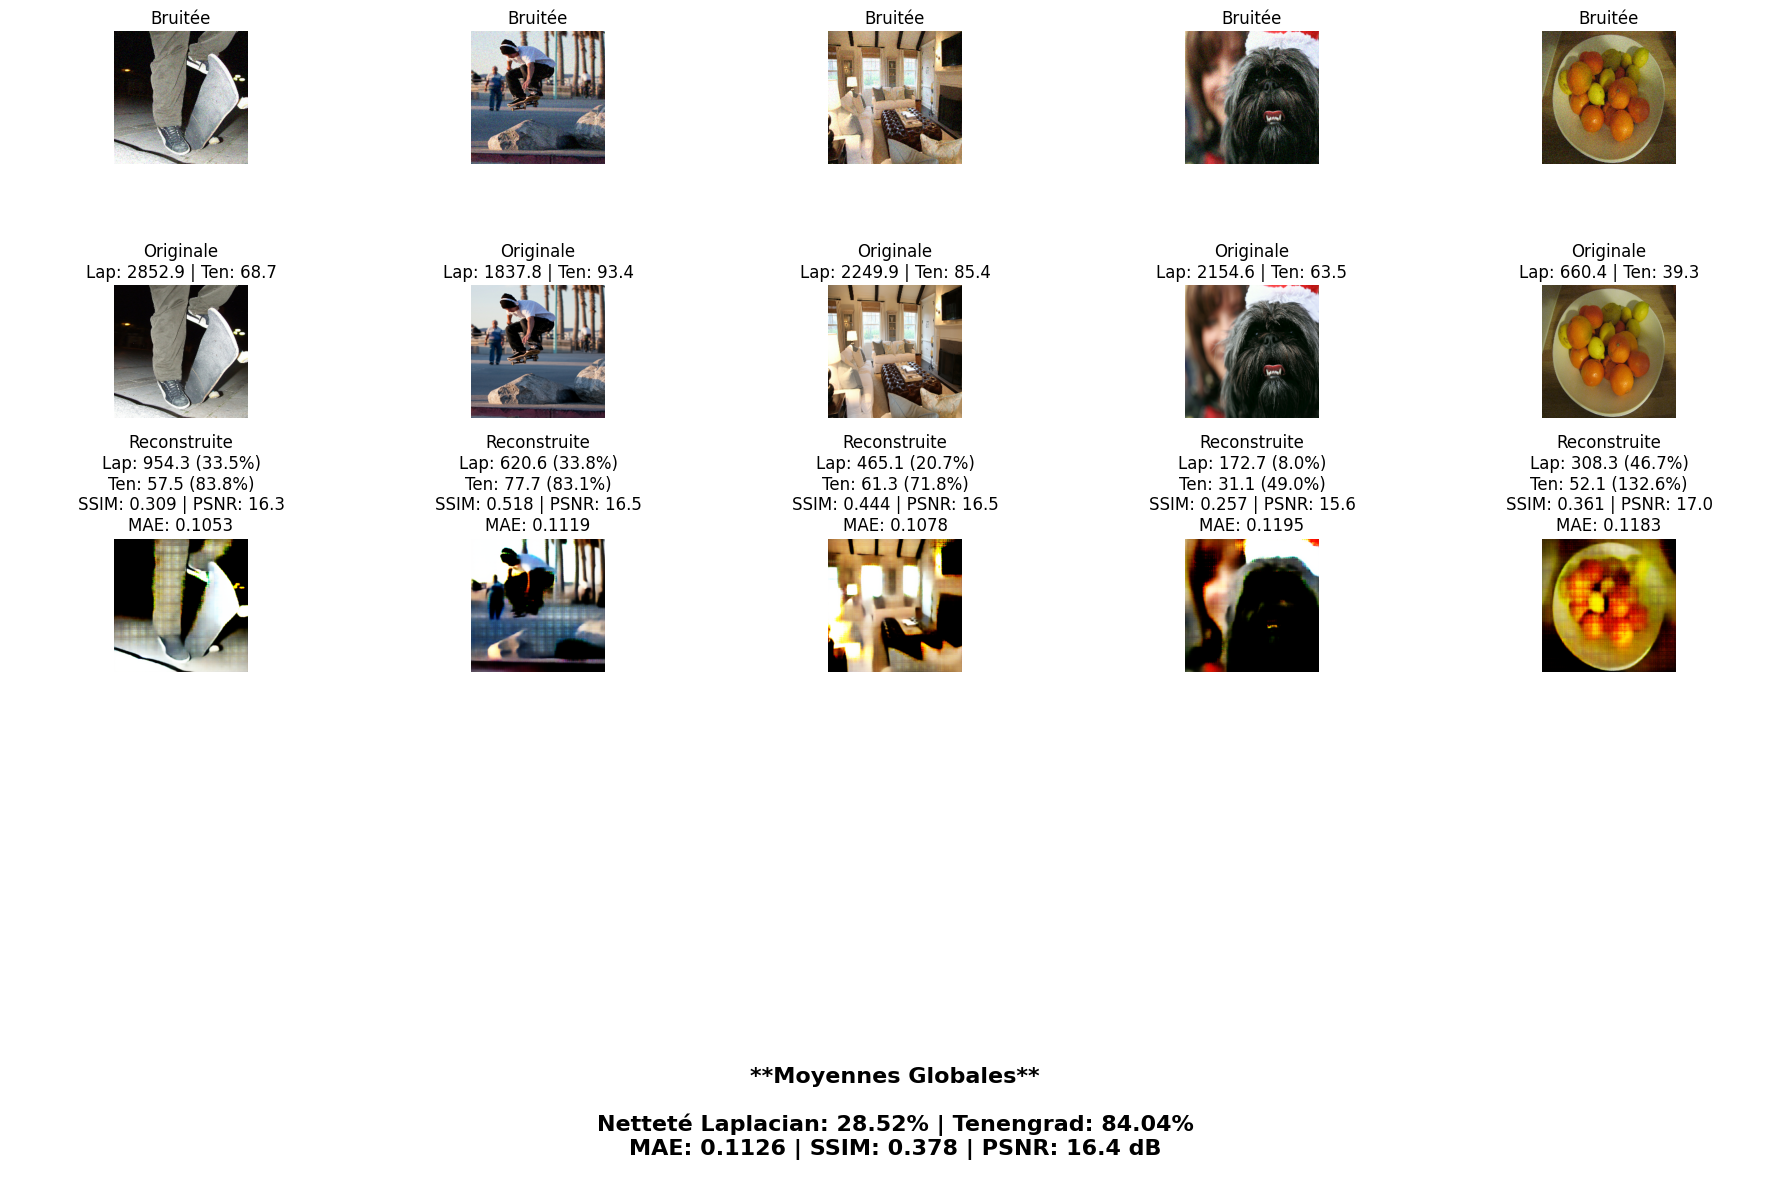

In [ ]:
show_original_vs_decoded_with_sharpness(noisy_test_ds, test_ds, autoencoder, n=5)